In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib.patches import Patch

import os
import scanpy as sc

import seaborn as sns
import snapatac2 as snap

snap.__version__



plt.rcParams['figure.dpi'] = 167
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6




/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
cat_colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
cat_colors_map = dict(zip(unique_categories, cat_colors_list))    


jitter_width = 0.25
position_offset = [0] + [-jitter_width] * 3 + [jitter_width] * 3  # Adjust offsets for each category
cat_position_map = dict(zip(unique_categories, position_offset))


scanpy_colors = [    
    '#1f77b4',
    '#ff7f0e', 
    '#2ca02c',
    '#d62728', 
    '#9467bd', 
    '#8c564b', 
    '#e377c2', 
    '#bcbd22', 
    '#17becf', 
    '#c7c7c7', 
    '#ffbb78',
    '#98df8a']
scanpy_cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
scanpy_color_map = dict(zip(scanpy_cluster, scanpy_colors))

In [5]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, s = 15, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=s, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size


In [6]:
SADEvsCR_unique_categoris = ['both', 'entropy_only', 'cr_only', 'none', 'tss_only']
SADEcsCR_labels = ['Overlap', 'SADE unique', 'CR unique', 'Neither', 'TSSe unique']
SADEvsCR_colors = ['#0C5B28', '#2E5BFF', '#F59E0B', '#94A3B8', '#D81B60']

SADEvsCR_colors_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_colors))
SADEvsCR_label_map = dict(zip(SADEvsCR_unique_categoris, SADEcsCR_labels))

jitter_width = 0.25
SADEvsCR_position_offset = [0] + [-jitter_width] * 2 + [jitter_width] * 2  # Adjust offsets for each category
SADEvsCR_cat_position_map = dict(zip(SADEvsCR_unique_categoris, SADEvsCR_position_offset))

## Load Data

In [7]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info['index'] = union_cell_info.index.map(lambda x: x + '-1')

union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,index
atac_bc,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,AAACAAGCATTTCTTC-1


In [8]:
frip_score_file = os.path.join(Union_cell_subdir, 'frip_cells_info.tsv')
frip_score_info = pd.read_csv(frip_score_file, sep='\t', index_col=0)
frip_score_info['index'] = frip_score_info.index.map(lambda x: x + '-1')
frip_score_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,...,FRIP_entropy_peaks,Nfrag_in_tsse_peaks,FRIP_tsse_peaks,Nfrag_in_cr_peaks,FRIP_cr_peaks,Nfrag_in_common_peaks,FRIP_common_peaks,Nfrag_in_blacklist,blacklist_ratio,index
atac_bc,,,,,,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,...,0.795605,1933,0.801410,1785,0.740050,1932,0.800995,19.0,0.007877,AAACAAGCAAGTTAGT-1
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,...,0.204540,1877,0.207863,1635,0.181063,1878,0.207973,90.0,0.009967,AAACAAGCATTTCTTC-1


In [9]:
amulet_doublet_atac_file = os.path.join(Union_cell_subdir, 'AMULET_output/MultipletBarcodes_01.txt')
doublet_atac_barcodes = pd.read_csv(amulet_doublet_atac_file, header=None)
doublet_atac_barcodes.columns = ['barcodes']
doublet_atac_barcodes['atac_bc'] = doublet_atac_barcodes['barcodes'].str.split('-').str[0]
doublet_atac_barcodes.head(2)

,barcodes,atac_bc
0,AAAGCCTAGGATTATG-1,AAAGCCTAGGATTATG
1,AAAGGCGCACTAATCC-1,AAAGGCGCACTAATCC


In [10]:
data_filter = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered.h5ad'))

# filtered_leiden_file = os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_unioncells_filtered_obs.csv')
# data_filter.obs[[ 'leiden', 'filtered_leiden']].to_csv(
#     filtered_leiden_file)

In [11]:

data = sc.read_h5ad(os.path.join(Union_cell_subdir, '_SNAPataC_analysis', 'binnedGenome_all_unioncells.h5ad'))

data.obs['filtered_leiden'] = data.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')
data.obs['amulet_doublet_atac'] = data.obs.index.isin(doublet_atac_barcodes['barcodes'])

data.obs['debris_doublets_flag'] = data.obs.apply(lambda row: 
    'debrisNdoublet' if row['DNA_debris'] == 'YES' and row['amulet_doublet_atac'] == True \
        else ('doublets' if row['amulet_doublet_atac'] == True \
            else ('Debris' if row['DNA_debris'] == 'YES' else 'clean')), axis=1)


In [12]:
data

AnnData object with n_obs × n_vars = 2384 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'debris_doublets_flag'
    var: 'count', 'selected'
    uns: 'DNA_debris_colors', 'TSS_profile', '_3set_identified_by_atac_colors', 'amulet_doublet_atac_colors', 'frac_overlap_TSS', 'leiden_RNA_scVI_colors', 'leiden_colors', 'leiden_scanpy', 'leiden_scanpy_colors', 'library_tsse', 'reference_sequences', 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap', 'fragment_paired'
    obsp: 'distances'

In [13]:
col_list = [ '_3set_identified_by_atac', 'debris_doublets_flag', 'filtered_leiden', 'leiden_RNA_scVI',  'amulet_doublet_atac', 'DNA_debris', 'rna_pass_CR']
data.obs[col_list].to_csv(os.path.join(Union_cell_subdir, '_union_cell_final_info.csv'), header=True, sep='\t')

In [14]:
data.obs[(data.obs['debris_doublets_flag']== 'clean') & (data.obs['filtered_leiden']!= '0')].groupby(['rna_pass_CR']).size()

rna_pass_CR
False      45
True     1949
dtype: int64

In [15]:
data.obs.groupby(['rna_pass_CR', 'debris_doublets_flag', 'filtered_leiden']).size().unstack(fill_value=0)

filtered_leiden                     0    1   10   11    2    3    4    5    6  \
rna_pass_CR debris_doublets_flag                                                
False       Debris                  0    0    0    0    0    0    0    0    0   
            clean                 285    1    2    1    5   12    8    0    7   
            debrisNdoublet          0    0    0    0    0    0    0    0    0   
            doublets                0    0    0    0    0    0    0    0    0   
True        clean                   7  239  138  135  220  193  189  190  171   
            debrisNdoublet          0    0    0    0    0    0    0    0    0   
            doublets                0    0    0    0    0    0    0    0    0   

filtered_leiden                     7    8    9  debrisOdoublets  
rna_pass_CR debris_doublets_flag                                  
False       Debris                  0    0    0                2  
            clean                   1    1    7                0  
            debrisNdoublet          0    0    0                6  
            doublets                0    0    0                2  
True        clean                 177  156  141                0  
            debrisNdoublet          0    0    0               14  
            doublets                0    0    0               74

In [16]:
data_filter.obs.groupby(['filtered_leiden', '_3set_identified_by_atac']).size().unstack(fill_value=0)

/tmp/ipykernel_3529770/4095031969.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_filter.obs.groupby(['filtered_leiden', '_3set_identified_by_atac']).size().unstack(fill_value=0)


_3set_identified_by_atac,CR unique,"CR+TSS, not SADE",SADE unique,"SADE+CR, not TSS","SADE+TSS, not CR",TSS unique,common
filtered_leiden,,,,,,,
0,7,5,65,10,7,189,9
1,0,0,0,0,3,0,237
2,5,6,4,6,16,0,188
3,13,7,15,12,35,0,123
4,0,0,0,0,4,0,193
5,0,0,0,0,1,0,189
6,11,14,19,19,22,0,93
7,0,0,0,0,1,0,177
8,0,0,0,0,5,0,152


In [17]:
data.obs.groupby(['rna_pass_CR']).size()

rna_pass_CR
False     340
True     2044
dtype: int64

In [18]:
data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()

/tmp/ipykernel_3529770/2208233013.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs[(data.obs['amulet_doublet_atac'] == True) | (data.obs['DNA_debris'] == 'YES') ].groupby(['_3set_identified_by_atac']).size()


_3set_identified_by_atac
CR unique           22
CR+TSS, not SADE     0
SADE unique          0
SADE+CR, not TSS    11
SADE+TSS, not CR     0
TSS unique           0
common              65
dtype: int64

In [19]:
data.obs.groupby(['debris_doublets_flag', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_3529770/3837807011.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.obs.groupby(['debris_doublets_flag', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,2,3,4,5,6,7,8,9,10,11,no_rna_info
debris_doublets_flag,,,,,,,,,,,,,
Debris,0,0,0,0,0,0,0,0,0,0,0,2,0
clean,497,348,274,272,261,221,204,98,43,41,23,1,3
debrisNdoublet,0,3,1,0,0,0,0,0,1,1,0,14,0
doublets,11,12,14,6,0,3,5,3,19,1,0,2,0


In [20]:
data.obs['debris_doublets_flag_mod'] = data.obs['debris_doublets_flag'].replace({'debrisNdoublet': 'debris,doublet', 'doublets': 'debris,doublet', 'Debris': 'debris,doublet'})
data.obs['_2set_identified_by_atac_SC_mod'] = data.obs['_2set_identified_by_atac_SC'].replace('none', 'tss_only')

/tmp/ipykernel_3529770/323247394.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.obs['_2set_identified_by_atac_SC_mod'] = data.obs['_2set_identified_by_atac_SC'].replace('none', 'tss_only')


# Vis

# TSSe 

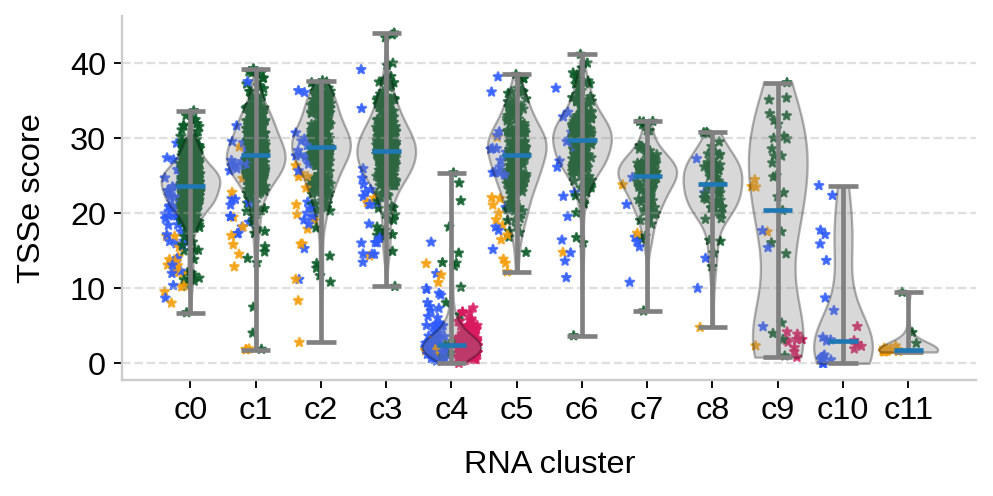

In [21]:
fig= plt.figure(figsize=(6.6, 5))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.3, 1], hspace=0)
ax = fig.add_subplot(gs[0])

RNA_cluster_list = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', 'no_rna_info']
RNA_cluster_list = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
tsse_score_list = [
    data.obs[data.obs['leiden_RNA_scVI'] == cluster]['tsse'] for cluster in RNA_cluster_list
]
tsse_color_list = [
    data.obs.loc[data.obs['leiden_RNA_scVI'] == cluster, '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map) for cluster in RNA_cluster_list
]

jitter_position_offset = [
    data.obs.loc[data.obs['leiden_RNA_scVI'] == cluster, '_2set_identified_by_atac_SC_mod'].map(SADEvsCR_cat_position_map) for cluster in RNA_cluster_list
]

x_positions = np.arange(len(RNA_cluster_list))
v1 = ax.violinplot(tsse_score_list, positions=x_positions, widths=0.9, showmeans=False, showmedians=True)

for met in ['cbars', 'cmins', 'cmaxes']:
    v1[met].set_color('grey')
for i, body in enumerate(v1['bodies']):
    body.set_facecolor('grey')
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(tsse_score_list):
    add_jittered_points(ax, group_data,x_positions[i] + jitter_position_offset[i], color=tsse_color_list[i], alpha=0.8, s=15, marker='*', 
                        edgecolors=tsse_color_list[i],
                        jitter_width=0.15)


ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(['c' + cluster for cluster in RNA_cluster_list], fontweight='medium', rotation=0, ha='center')
ax.set_ylabel('TSSe score',  labelpad=10)
ax.set_xlabel('RNA cluster', labelpad=10)


for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p4.png'), bbox_inches='tight', dpi=300)
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p4.pdf'), bbox_inches='tight')

# Gene activity score

In [22]:
gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
gene_matrix

AnnData object with n_obs × n_vars = 2384 × 60606
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'debris_doublets_flag', 'debris_doublets_flag_mod', '_2set_identified_by_atac_SC_mod'

In [23]:
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
gene_matrix

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData object with n_obs × n_vars = 2384 × 58486
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'rna_pass_CR', 'atac_pass_CR', 'atac_pass_entropy', 'atac_pass_archr_TSS', '_2set_identified_by_atac_SC', '_2set_identified_by_atac_ST', '_3set_identified_by_atac', 'DNA_debris', 'amulet_doublet_atac', 'leiden_RNA_scVI', 'total_fragments', 'FRIP_raw_peaks', 'FRIP_entropy_peaks', 'FRIP_tss_peaks', 'FRIP_frip_peaks', 'nucleosome_signal', 'tsse', 'leiden', 'leiden_scanpy', 'filtered_leiden', 'debris_doublets_flag', 'debris_doublets_flag_mod', '_2set_identified_by_atac_SC_mod'
    var: 'n_cells'
    uns: 'log1p'

In [24]:
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

## Vis in heatmap

In [35]:
debris_or_doublet_cat= [ 'doublets', 'debrisNdoublet', 'Debris']
debris_or_doublet_map = dict(zip(debris_or_doublet_cat, [  "#a50026", '#a50026', "#a50026"]))


pass_cr_map = {False: "#a50026"} # True: (0,0,0,0), }
dna_debris_map = {'YES': "#a50026"}#, 'NO': '#FFFFFF'}

amulet_doublet_colors_map = {True: '#a50026'} # False: "#FFFFFF", }

filtered_leiden_colors_map = dict(zip( scanpy_cluster + ['debrisOdoublets'], scanpy_colors + ['black'],))

In [36]:
gene_matrix.obs['filtered_leiden'] = gene_matrix.obs.index.map(data_filter.obs['filtered_leiden']).fillna('debrisOdoublets')

In [37]:
gene_matrix.obs['amulet_doublet_atac'].value_counts()

amulet_doublet_atac
False    2288
True       96
Name: count, dtype: int64

In [38]:
quiescent_regulation_genes = ['TP53',    'IKZF1',  'SATB1', 'YY1', 'TFEB', 'RBPJ'] #, 'HES1', ]

Tcells= ['IL7R',] #'CD3G', 'CD3E', 'CD3D',  ] 
B_cell = ['MS4A1', 'CD79A']# , 'CD19', ]
NK = [ 'FCGR3A', 'NCAM1'] # NKG7',FCGR3A', 'NCAM1'
mono = [ 'CD14',   'CD68',   ]# ,  CD14, FCGR1A, CD68
naiveTcells = [ "CCR7",	  ]#  "CCR7",	 'IL7R',
DC=[  'CD1C',  ] # 'SERPINF1',  
cytotoxic_T = ['CD8A', 'CD8B',]
#mono_or_DC = ['HLA-DRA'] # for umap 
#naiveThelper = [   'CD4', ] # for umap 

housekeeping_genes = ['GNB1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A',] # 'CMPK1', 'COX7A2L', 'SF3B1', 'CTDSP1']

marker_genes_redor =Tcells  + naiveTcells +  cytotoxic_T+  NK+ mono + DC + B_cell    + housekeeping_genes 

marker_genes_redor_delux = marker_genes_redor + quiescent_regulation_genes

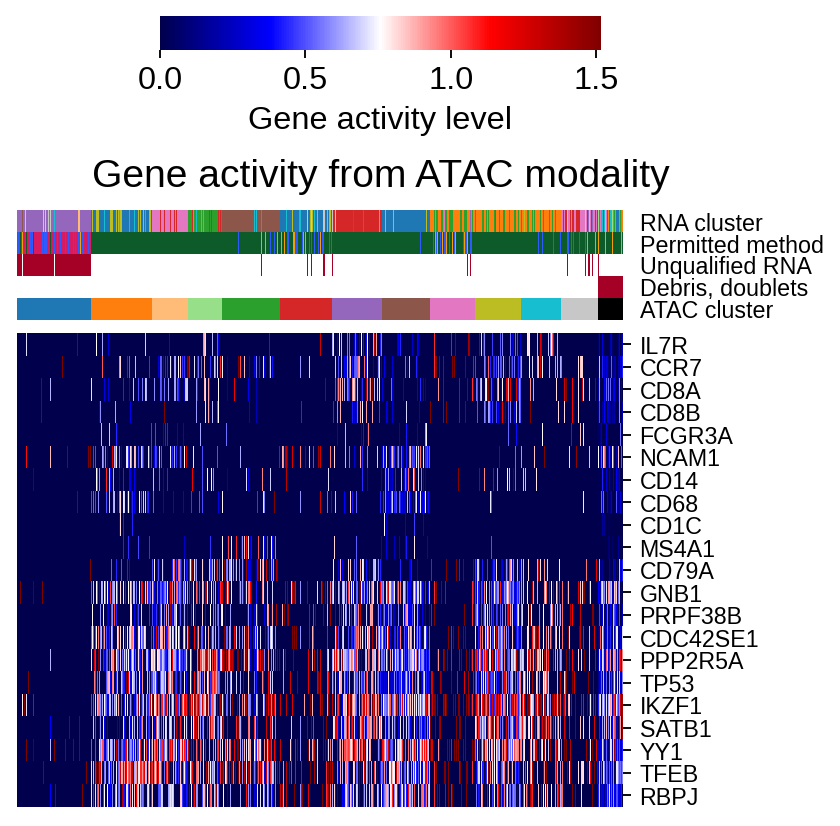

In [49]:
# heatmap          
mat = gene_matrix[:, marker_genes_redor_delux].X.toarray()
df = pd.DataFrame(mat, index=gene_matrix.obs.index, columns= marker_genes_redor_delux).T

vmean = df.values.mean()
vsd = df.values.std()
vmin= 0.
vmax = np.min((df.values.max(), vmean + 3*vsd))
vcenter = vmax/2

#Create metadata for the columns
metadata = gene_matrix.obs[['leiden_RNA_scVI', '_3set_identified_by_atac', '_2set_identified_by_atac_SC_mod', 'DNA_debris', 'rna_pass_CR', 'leiden', 'filtered_leiden', 'amulet_doublet_atac', 'debris_doublets_flag']].copy()
cell_index = gene_matrix.obs['filtered_leiden'].sort_values().index


col_colors = pd.DataFrame({
    'RNA cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map).fillna('black'),
    'Permitted method': metadata['_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map),
    'Unqualified RNA': metadata['rna_pass_CR'].map(pass_cr_map),
    'Debris, doublets': metadata['debris_doublets_flag'].map(debris_or_doublet_map),
    # 'DNA-debris': metadata['DNA_debris'].map(dna_debris_map),
    # 'Amulet doublet': metadata['amulet_doublet_atac'].map(amulet_doublet_colors_map),
    #'atac_leiden': metadata['leiden'].map(scanpy_color_map),
    'ATAC cluster': metadata['filtered_leiden'].map(filtered_leiden_colors_map),
}, index=metadata.index)

# 4. Plot the clustermap
g = sns.clustermap(df.loc[:, cell_index], col_colors=col_colors.loc[cell_index], cmap='seismic', #cmap='seismic', 
                   figsize=(6.6, 5), col_cluster=False, xticklabels=False, row_cluster=False, yticklabels=True,
                   cbar_pos=(0.3, 0.96, 0.4, 0.04), 
                   cbar_kws={"orientation": "horizontal", 'label': 'Gene activity level'},
                  vmin=vmin, vmax=vmax,  center= vcenter
                  )
g.tick_params(axis='y', labelsize=10)
# g.ax_heatmap.tick_params(axis='y', labelsize=10)
g.ax_row_dendrogram.set_visible(False) # Hide Row tree
g.ax_col_colors.tick_params(axis='y', labelsize=10,    labelright=True, right=False)


g.fig.suptitle('Gene activity from ATAC modality',
               y=0.83) #
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig5_p1.png'), dpi=600, bbox_inches='tight')
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig5_p1.pdf'),  bbox_inches='tight')

## Reorder cells to have consistency with RNA heatmap

In [40]:
rna_cell_index_file = os.path.join(Union_cell_subdir, '_unioncell_rna_order_index.csv')
rna_cell_index = pd.read_csv(rna_cell_index_file, index_col=0, header=0)
rna_cell_index['atac_barcodes-1'] = rna_cell_index['atac_barcodes'] + '-1'
rna_cell_index = rna_cell_index.set_index('atac_barcodes-1')
print(rna_cell_index.shape)
rna_cell_index.head(2)

(2381, 2)


,rna_barcodes,atac_barcodes
atac_barcodes-1,,
GTTTGGTGTGCAGTAA-1,TTTGTGGCAGTATGTT,GTTTGGTGTGCAGTAA
GGTCATGAGCTAAATG-1,GCTAGTGTCCCGTTAC,GGTCATGAGCTAAATG


In [41]:
# 3 cells do not have RNA data and only ATAC, do need to add to the index for heat map plot's consistency
for cell in gene_matrix.obs.index:
    if cell not in rna_cell_index['atac_barcodes']:
        rna_cell_index.loc[cell, 'rna_barcodes'] =None

In [42]:
rna_cell_index['rna_barcodes'].isna().sum()

np.int64(3)

In [43]:
rna_cell_index.tail(5)

,rna_barcodes,atac_barcodes
atac_barcodes-1,,
TGCGCCTCATCCTGCA-1,AAGTGTTGTTTCCTCC,TGCGCCTCATCCTGCA
TCCTCCATCAGGTTCC-1,TGAAGTGAGGATTGAG,TCCTCCATCAGGTTCC
CGAATAATCTCACTTC-1,None,NaN
CGGTTTATCCTAAATC-1,None,NaN
GTTAGGAGTGCTCATG-1,None,NaN


In [44]:
metadata['leiden_RNA_scVI']

AAACAAGCAAGTTAGT-1    3
AAACAAGCATTTCTTC-1    0
AAACCGCCAACGGTAC-1    3
AAACCGCCAGAAACCC-1    5
AAACGAACACCTGTAT-1    8
                     ..
TTTGGAGCATAAGTCG-1    2
TTTGTCGAGCTAGTTT-1    0
TTTGTGAGTCATCACG-1    3
TTTGTGAGTGCTCATG-1    7
TTTGTGAGTTGAGTCT-1    2
Name: leiden_RNA_scVI, Length: 2384, dtype: category
Categories (13, object): ['0', '1', '2', '3', ..., '9', '10', '11', 'no_rna_info']

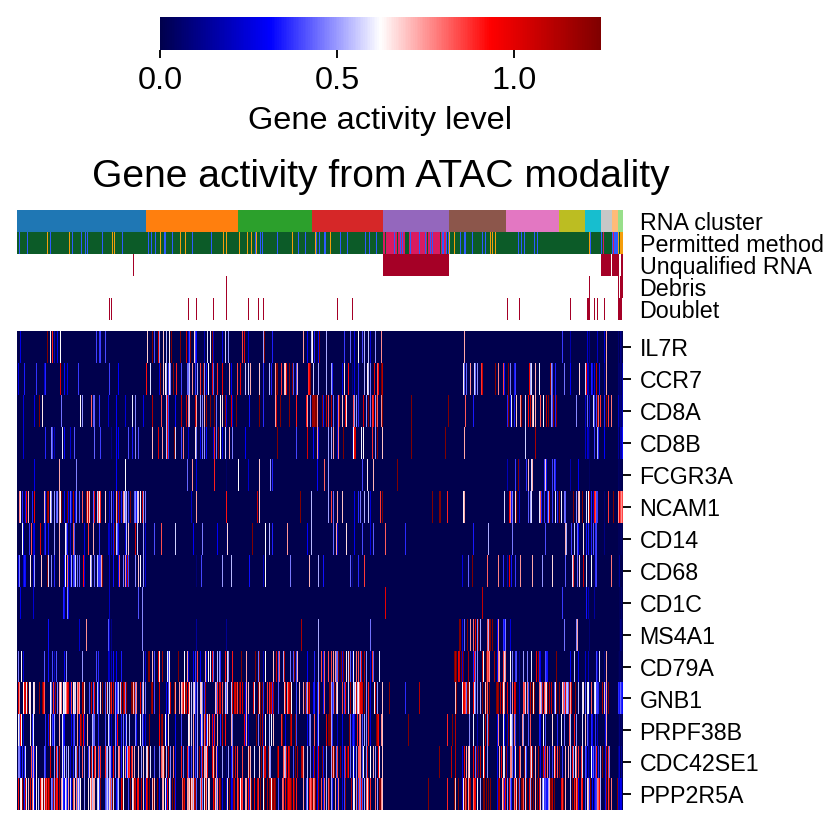

In [50]:
np.random.seed(42)  # For reproducibility of jitter
mat = gene_matrix[:, marker_genes_redor].X.toarray()
df = pd.DataFrame(mat, index=gene_matrix.obs.index, columns= marker_genes_redor).T

vmean = df.values.mean()
vsd = df.values.std()
vmin= 0.
vmax = np.min((df.values.max(), vmean + 3*vsd))
vcenter = vmax/2

#Create metadata for the columns
metadata = gene_matrix.obs[['leiden_RNA_scVI', '_2set_identified_by_atac_SC_mod', 'debris_doublets_flag', 'rna_pass_CR', 'leiden', 'filtered_leiden', 'DNA_debris', 'amulet_doublet_atac']].copy()


col_colors = pd.DataFrame({
    'RNA cluster': metadata['leiden_RNA_scVI'].map(scanpy_color_map).fillna('black'),
    'Permitted method': metadata['_2set_identified_by_atac_SC_mod'].map(SADEvsCR_colors_map),
    'Unqualified RNA': metadata['rna_pass_CR'].map(pass_cr_map),
    #'Debris, doublets': metadata['debris_doublets_flag'].map(debris_or_doublet_map),
    'Debris': metadata['DNA_debris'].map(dna_debris_map),
    'Doublet': metadata['amulet_doublet_atac'].map(amulet_doublet_colors_map),
}, index=metadata.index)

num_color_rows = col_colors.shape[1]
dynamic_ratio = 0.018 * num_color_rows

cell_index = rna_cell_index.index
cell_index.name = None

# 4. Plot the clustermap
g = sns.clustermap(df.loc[:,cell_index], col_colors=col_colors.loc[cell_index], cmap='seismic',  linewidths=0, 
                   figsize=(6.6, 5), col_cluster=False, xticklabels=False, row_cluster=False, yticklabels=True,
                   cbar_pos=(0.3, 0.96, 0.4, 0.04), # Horizontal bar at bottom center
                   cbar_kws={"orientation": "horizontal", 'label': 'Gene activity level'}, #colors_ratio=dynamic_ratio,
                   vmin=vmin, vmax=vmax,  center= vcenter
                  )

g.tick_params(axis='y', labelsize=10)
g.ax_heatmap.tick_params(axis='y', labelsize=10)
g.ax_row_dendrogram.set_visible(False) # Hide Row tree
g.ax_col_colors.tick_params(axis='y', labelsize=10,    labelright=True, right=False)


g.fig.suptitle('Gene activity from ATAC modality',
               y=0.83) #
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p5.png'), dpi=600, bbox_inches='tight')
g.savefig(os.path.join(os.getcwd(), '_figures', 'fig4_p5.pdf'),  bbox_inches='tight')

In [51]:
gene_matrix.obs.groupby(['rna_pass_CR', 'leiden_RNA_scVI']).size().unstack(fill_value=0)

/tmp/ipykernel_3524291/932049625.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_matrix.obs.groupby(['rna_pass_CR', 'leiden_RNA_scVI']).size().unstack(fill_value=0)


leiden_RNA_scVI,0,1,2,3,4,5,6,7,8,9,10,11,no_rna_info
rna_pass_CR,,,,,,,,,,,,,
False,1,2,0,2,261,0,1,0,0,37,23,10,3
True,507,361,289,276,0,224,208,101,63,6,0,9,0


## Umap for each marker 

... storing 'filtered_leiden' as categorical
... storing 'debris_doublets_flag' as categorical
... storing 'debris_doublets_flag_mod' as categorical


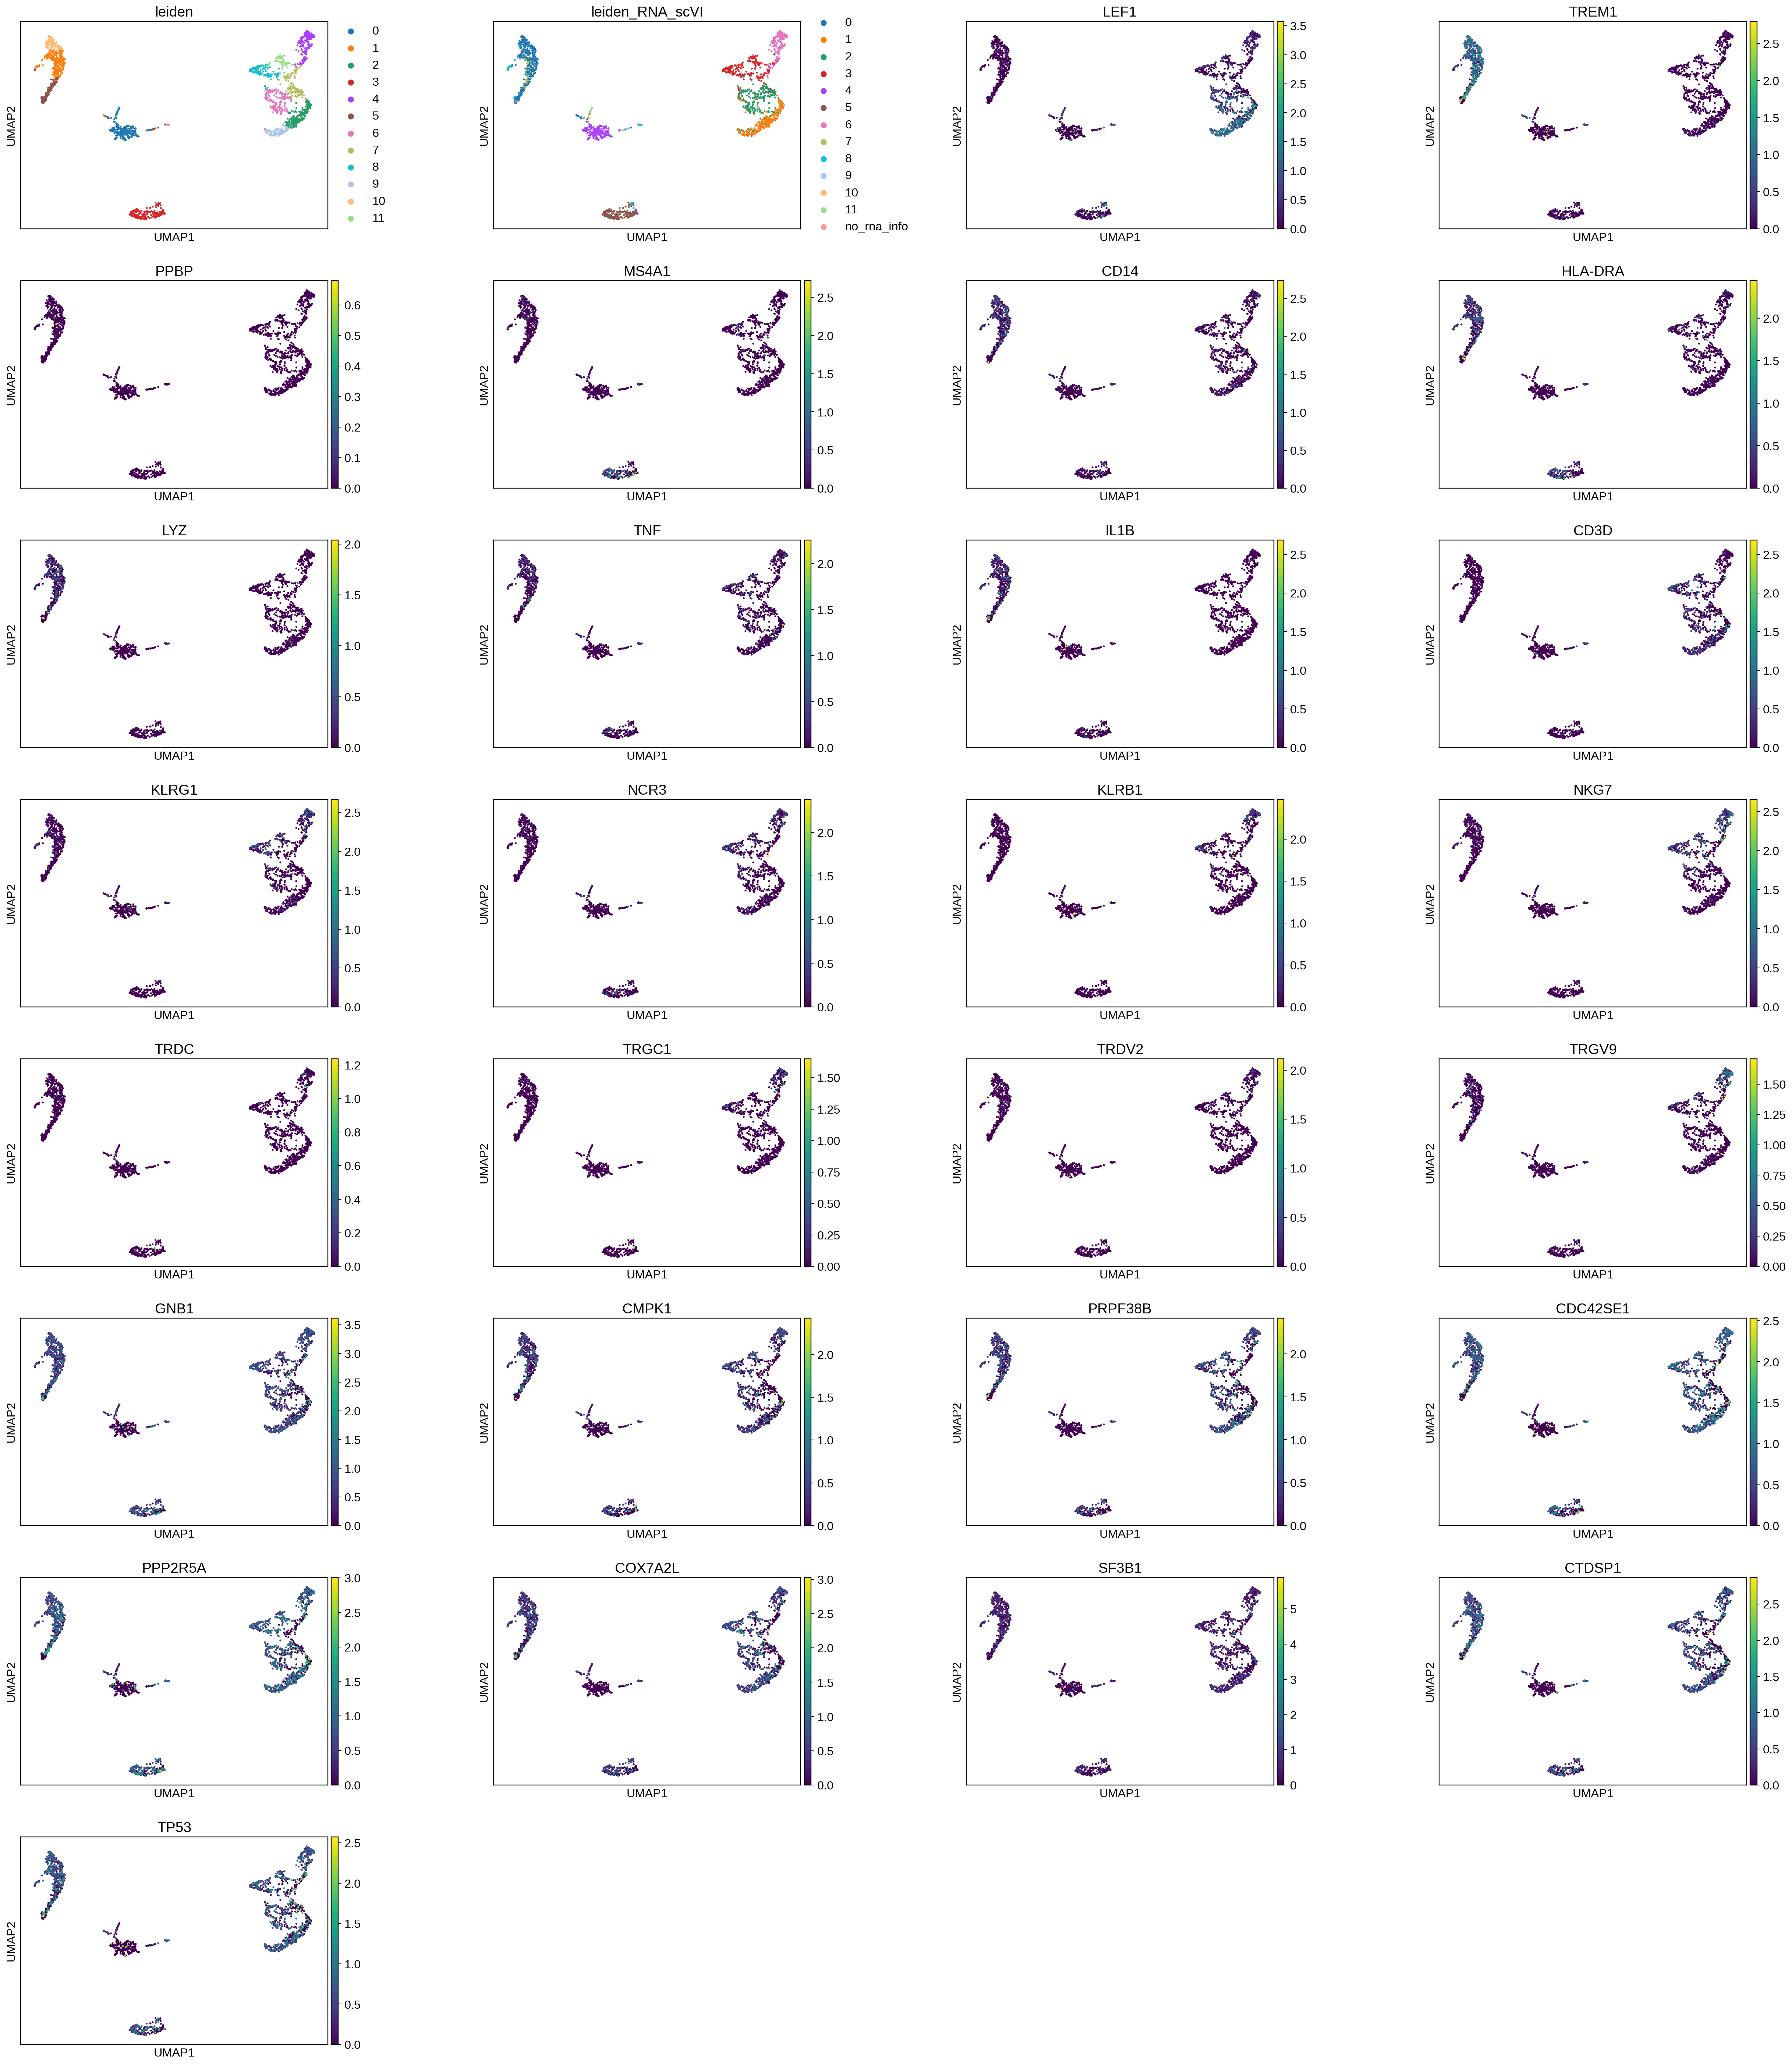

In [52]:
mono = ['CD14',   'HLA-DRA',  'LYZ', 'TNF', 'IL1B']
NK = [  'CD3D', 'KLRG1',   'NCR3','KLRB1', 'NKG7']
gamma_delta_T = ['TRDC',   'TRGC1','TRDV2', 'TRGV9']
B_cell = ['MS4A1']
housekeeping_genes = ['GNB1','CMPK1', 'PRPF38B',  'CDC42SE1', 'PPP2R5A', 'COX7A2L', 'SF3B1', 'CTDSP1']
marker_genes = ['LEF1',  'TREM1',  'PPBP'] + B_cell +  mono + NK + gamma_delta_T + housekeeping_genes

quiescent_regulation_genes = ['TP53',  ]
sc.pl.umap(gene_matrix, color=['leiden', 'leiden_RNA_scVI'] + marker_genes + quiescent_regulation_genes, s=20, ncols=4, wspace=0.4)

# Identified cell quality

In [21]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_CR'].value_counts()

atac_pass_CR
True     1830
False     164
Name: count, dtype: int64

In [22]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_entropy'].value_counts()

atac_pass_entropy
True     1934
False      60
Name: count, dtype: int64

In [23]:
data_filter.obs.loc[data_filter.obs['filtered_leiden'] != '0']['atac_pass_archr_TSS'].value_counts()

atac_pass_archr_TSS
True     1857
False     137
Name: count, dtype: int64

In [24]:
data_filter.obs.groupby(['atac_pass_CR', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_CR,,
False,272,153
True,58,1803


In [25]:
data_filter.obs.groupby(['atac_pass_entropy', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_entropy,,
False,203,58
True,127,1898


In [26]:
data_filter.obs.groupby(['atac_pass_archr_TSS', 'rna_pass_CR']).size().unstack(fill_value=0)

rna_pass_CR,False,True
atac_pass_archr_TSS,,
False,94,125
True,236,1831


## Vis above 

In [27]:
# 1st originally the number of nuclei identified by each method 
filtering_methods = ['atac_pass_entropy', 'atac_pass_CR', 'atac_pass_archr_TSS']
filtering_methods_names = ['SADE droplets', 'CR droplets', 'TSSe droplets']
filtering_methods_names_map = dict(zip(filtering_methods, filtering_methods_names))
Nnuclei_per_method = pd.DataFrame({
    #
    'Initial': [data.obs[method].sum() for method in filtering_methods]
}, index=filtering_methods_names)


# 2nd the number of post-QC nuclei that removes DNA-debris, doublets, and inefficient ATAC features for downstream analysis 
data_postQC = data.obs[ ~(data.obs['filtered_leiden'].isin(['debrisOdoublets', '0']))].copy()
Nuclei_per_method_postATACQC = pd.DataFrame({
    # Clean meaning no DNA-debris, no doublets, and good ATAC features, which are the nuclei used for downstream analysis
    'Clean': [ 
        data_postQC[method].sum() for method in filtering_methods
    ]
}, index=filtering_methods_names)


# 3rd the number of nuclei passed ATAC QC with valid RNA data
data_with_good_RNA = data_postQC[data_postQC['rna_pass_CR'] == True].copy()
Nuclei_per_method_goodRNA = pd.DataFrame({
    'Qualified': [
        data_with_good_RNA[method].sum() for method in filtering_methods
    ]
}, index=filtering_methods_names)


combined = pd.concat([Nnuclei_per_method,  Nuclei_per_method_postATACQC, Nuclei_per_method_goodRNA], axis=1)
# combined = combined.set_index('method')

In [28]:
combined

,Initial,Clean,Qualified
SADE droplets,2101,1934,1894
CR droplets,1959,1830,1797
TSSe droplets,2132,1857,1826


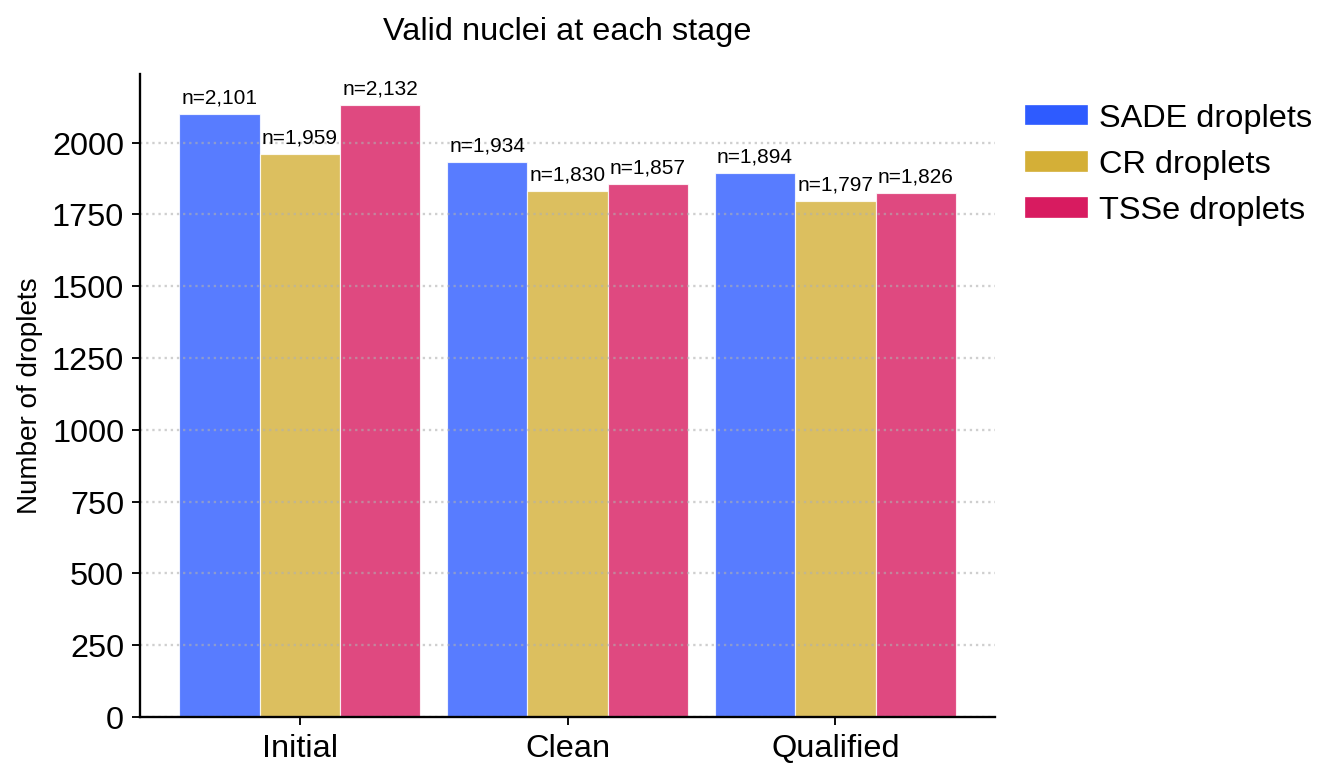

In [32]:
fig, ax = plt.subplots(figsize=(6.6, 5))

# SADE, CR, TSS
methods = combined.index
colors = ['#2E5BFF', "#D4AF37", '#D81B60',]
n_stages = combined.shape[1]
x_positions = np.arange(len(methods))
width = 0.3

for i, stage in enumerate(combined.columns):
    pos = x_positions[i] + (np.arange(n_stages) - (n_stages-1)/2) * width
    
    bars = ax.bar(pos, combined[stage], width, 
                  color=colors, 
                  edgecolor='white', 
                  linewidth=0.5,
                  alpha=0.8)
    
    ax.bar_label(bars, 
                labels=[f'n={int(bar.get_height()):,}' for bar in bars], 
                padding=3, 
                fontsize=9, 
                rotation=0)
# 4. Formatting
ax.set_ylabel('Number of droplets', fontsize=12)
ax.set_title('Valid nuclei at each stage', fontsize=14, pad=15)

# Set ticks to the middle of the 3-bar groups
ax.set_xticks(x_positions)
ax.set_xticklabels(combined.columns)

# Custom Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=c, edgecolor='white', label=method) for c, method in zip(colors, methods)
]
ax.legend(handles=legend_elements,  frameon=False, bbox_to_anchor=(1.0, 1), loc='upper left', handletextpad=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.6)

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig5_p2.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig5_p2.pdf'))